# QAOA for Maximum Cut
## Part IV: Experiments — QAOA vs Classical Baselines

**Physics 565/656 · Spring 2026 · Sehong Park**

This notebook implements and compares QAOA against classical baselines
(Random, Greedy, Goemans-Williamson) on three graph instances
with distinct structural properties.

**Graphs:** $C_{10}$, $C_{10}$ + 3 chords, 3-regular ($n=10$)  
**Methods:** Random · Greedy (single-pass) · Greedy (best-of-5) · GW (SDP) · QAOA $p=1,2,3$


---
## 1. Setup

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cvxpy as cp
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

MASTER_SEED = 42
np.random.seed(MASTER_SEED)

# ── Core utilities ─────────────────────────────────────────────────
def cut_val(bits, edges):
    return sum(1 for i,j in edges if bits[i] != bits[j])

def exact_maxcut(edges, n):
    """Brute-force exact MaxCut (n ≤ 20)."""
    best = 0
    for x in range(2**n):
        bits = [(x >> i) & 1 for i in range(n)]
        best = max(best, cut_val(bits, edges))
    return best

print("Setup complete.")


Setup complete.


---
## 2. Graph Instances

| Graph | Structure | Role |
|-------|-----------|------|
| $C_{10}$ | 10-cycle | Sanity check; QAOA theoretically analyzed (2-regular) |
| $C_{10}$ + 3 chords | Cycle + long-range edges | Local structure disrupted; greedy struggles |
| 3-regular ($n=10$) | All degrees = 3 | Directly analyzed in Farhi et al. (2014) |

These three instances represent distinct structural regimes: a 2-regular cycle (analytically tractable), a cycle with long-range edges (disrupted locality), and a 3-regular graph (studied directly in Farhi et al. 2014).


In [2]:
n = 10

# ── C10 ──────────────────────────────────────────────────────────
G1 = nx.cycle_graph(n)
e1 = list(G1.edges())

# ── C10 + 3 chords ───────────────────────────────────────────────
G2 = nx.cycle_graph(n)
non_edges = [(i,j) for i in range(n) for j in range(i+2, n)
             if abs(i-j) > 1 and not (i == 0 and j == n-1)]
chord_idx = np.random.default_rng(0).choice(len(non_edges), size=3, replace=False)
CHORDS = [non_edges[c] for c in chord_idx]
for c in CHORDS:
    G2.add_edge(*c)
e2 = list(G2.edges())

# ── 3-regular n=10 ───────────────────────────────────────────────
G3 = nx.random_regular_graph(3, n, seed=7)
e3 = list(G3.edges())

GRAPHS = [
    (r'$C_{10}$',            G1, e1),
    (r'$C_{10}$ + 3 chords', G2, e2),
    (r'3-regular ($n=10$)',   G3, e3),
]

for name, G, edges in GRAPHS:
    opt = exact_maxcut(edges, n)
    print(f"{name}: |E|={len(edges)}, OPT={opt}, avg_degree={2*len(edges)/n:.1f}")
print(f"Chords added to G2: {CHORDS}")


$C_{10}$: |E|=10, OPT=10, avg_degree=2.0
$C_{10}$ + 3 chords: |E|=13, OPT=13, avg_degree=2.6
3-regular ($n=10$): |E|=15, OPT=13, avg_degree=3.0
Chords added to G2: [(3, 6), (2, 7), (4, 9)]


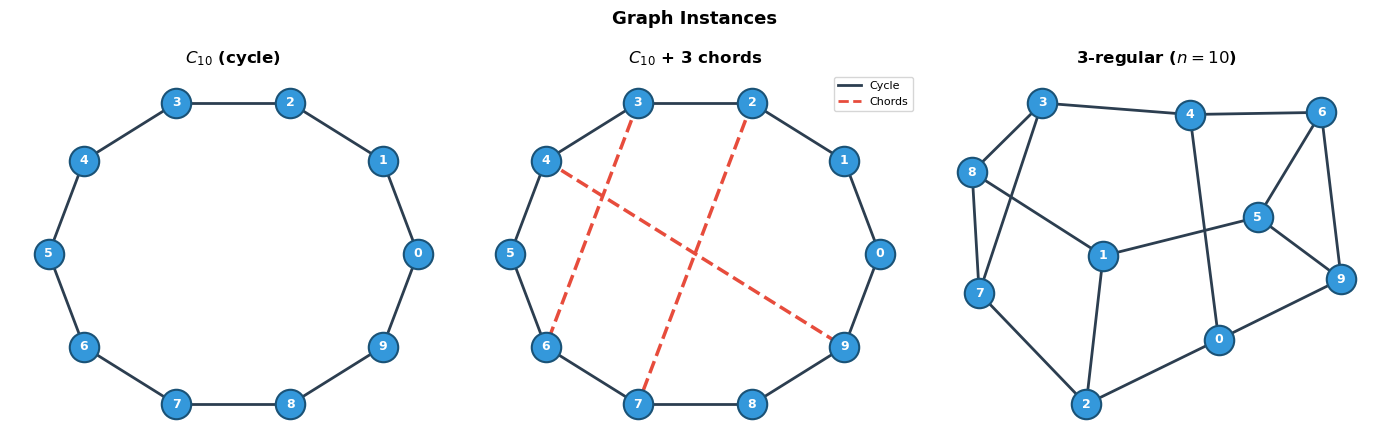

In [3]:
# ── Visualize ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
titles = [r'$C_{10}$ (cycle)', r'$C_{10}$ + 3 chords', r'3-regular ($n=10$)']

for ax, (name, G, edges), title in zip(axes, GRAPHS, titles):
    pos = nx.circular_layout(G) if G in [G1, G2] else nx.spring_layout(G, seed=MASTER_SEED)

    if G is G2:
        cycle_e = list(nx.cycle_graph(n).edges())
        chord_e = [e for e in G.edges()
                   if e not in cycle_e and (e[1],e[0]) not in cycle_e]
        nx.draw_networkx_edges(G, pos, edgelist=cycle_e, ax=ax,
                               edge_color='#2C3E50', width=2)
        nx.draw_networkx_edges(G, pos, edgelist=chord_e, ax=ax,
                               edge_color='#E74C3C', width=2.5, style='dashed')
        chord_patch = plt.Line2D([0],[0], color='#E74C3C', lw=2, ls='--', label='Chords')
        cycle_patch = plt.Line2D([0],[0], color='#2C3E50', lw=2, label='Cycle')
        ax.legend(handles=[cycle_patch, chord_patch], fontsize=8, loc='upper right')
    else:
        nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#2C3E50', width=2)

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color='#3498DB',
                           node_size=450, edgecolors='#1A5276', linewidths=1.5)
    nx.draw_networkx_labels(G, pos, ax=ax, font_color='white', font_size=9, font_weight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('Graph Instances', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('exp_graphs.png', dpi=130, bbox_inches='tight')
plt.show()


---
## 3. Classical Baselines

### Random Sampling
Expected ratio $\approx 0.50$ for any graph.

### Greedy Heuristic
Single random node ordering; each node assigned to maximize local cut.
**Best-of-5**: repeat 5 times, return the best — stronger baseline.

### Goemans-Williamson (SDP)
Solves the SDP relaxation $X \succeq 0$, $X_{ii}=1$,
maximizing $\frac{1}{2}\sum_{(i,j)\in E}(1-X_{ij})$.
Rounds via random hyperplane projection over 200 trials.
Best known polynomial-time guarantee: ratio $\geq 0.8786$.


In [4]:
# ── Classical algorithms ─────────────────────────────────────────
def random_ratio(edges, n, trials=5000):
    rng = np.random.default_rng(MASTER_SEED)
    return np.mean([cut_val(rng.integers(0,2,n).tolist(), edges) for _ in range(trials)])

def greedy_once(G, edges, seed):
    rng = np.random.default_rng(seed)
    adj = {v: list(G.neighbors(v)) for v in G.nodes()}
    order = rng.permutation(list(G.nodes())).tolist(); S = set()
    for v in order:
        if sum(1 for u in adj[v] if u not in S) >= sum(1 for u in adj[v] if u in S):
            S.add(v)
    return cut_val([(1 if v in S else 0) for v in range(len(G))], edges)

def greedy_single(G, edges, trials=300):
    return np.mean([greedy_once(G, edges, s) for s in range(trials)])

def greedy_best5(G, edges, trials=300):
    return np.mean([max(greedy_once(G, edges, s+k*1000) for k in range(5))
                    for s in range(trials)])

def goemans_williamson(edges, n, n_trials=200):
    """
    GW SDP relaxation + random hyperplane rounding.
    Solves: max (1/2) sum_{(i,j) in E} (1 - X_ij)
            s.t. X >= 0 (PSD), X_ii = 1
    """
    X = cp.Variable((n, n), symmetric=True)
    constraints = [X >> 0] + [X[i,i] == 1 for i in range(n)]
    objective = cp.Maximize(sum(0.5*(1 - X[i,j]) for i,j in edges))
    cp.Problem(objective, constraints).solve(solver=cp.SCS, verbose=False)

    eigvals, eigvecs = np.linalg.eigh(X.value)
    V = eigvecs @ np.diag(np.sqrt(np.maximum(eigvals, 0)))

    rng = np.random.default_rng(MASTER_SEED)
    best = 0
    for _ in range(n_trials):
        r = rng.standard_normal(n); r /= np.linalg.norm(r)
        bits = ((V @ r) >= 0).astype(int)
        best = max(best, cut_val(bits.tolist(), edges))
    return best

# Quick test
print("Testing classical baselines on C10...")
opt_test = exact_maxcut(e1, n)
print(f"  OPT={opt_test}")
print(f"  Random:   {random_ratio(e1,n)/opt_test:.4f}")
print(f"  Greedy-1: {greedy_single(G1,e1)/opt_test:.4f}")
print(f"  Best-5:   {greedy_best5(G1,e1)/opt_test:.4f}")
print(f"  GW:       {goemans_williamson(e1,n)/opt_test:.4f}")


Testing classical baselines on C10...
  OPT=10
  Random:   0.4992
  Greedy-1: 0.6587
  Best-5:   0.8100
  GW:       1.0000


---
## 4. QAOA Statevector Simulation

**Cost unitary** $U_C(\gamma) = e^{-i\gamma H_C}$:
diagonal phase oracle, $O(2^n)$ in simulation, $O(|E|)$ circuit depth on hardware.

**Mixer unitary** $U_B(\beta) = \bigotimes_i e^{-i\beta X_i}$:
separable, applied qubit by qubit.

**Optimizer:** COBYLA with 20 random restarts to avoid local minima.


In [5]:
# ── QAOA engine ──────────────────────────────────────────────────
def build_diag(edges, n):
    """Diagonal of H_C in the computational basis."""
    d = np.zeros(2**n)
    for x in range(2**n):
        bits = [(x >> i) & 1 for i in range(n)]
        d[x] = cut_val(bits, edges)
    return d

def apply_UB(psi, beta, n):
    """Apply mixer e^{-iβ H_B} qubit by qubit (separable: O(n·2^n))."""
    c, s = np.cos(beta), np.sin(beta)
    for q in range(n):
        psi = psi.reshape([2]*n); psi = np.moveaxis(psi,q,0).reshape(2,-1)
        psi = np.array([c*psi[0]-1j*s*psi[1], -1j*s*psi[0]+c*psi[1]])
        psi = psi.reshape([2]*n); psi = np.moveaxis(psi,0,q)
    return psi.reshape(-1)

def run_qaoa(edges, n, p, n_restarts=20):
    """
    QAOA for MaxCut. Returns (best_ratio, best_params).
    Maximizes F_p = <psi_p | H_C | psi_p> via COBYLA.
    """
    diag = build_diag(edges, n)
    OPT  = int(round(diag.max()))
    DIM  = 2**n

    def energy(theta):
        g = theta[:p]; b = theta[p:]
        psi = np.ones(DIM, dtype=complex) / np.sqrt(DIM)
        for k in range(p):
            psi = np.exp(-1j * g[k] * diag) * psi
            psi = apply_UB(psi, b[k], n)
        return -np.real(np.dot(psi.conj(), diag * psi))

    best = None
    for t in range(n_restarts):
        rng = np.random.default_rng(MASTER_SEED + t * 7)
        theta0 = rng.uniform(0, np.pi/2, 2*p)
        res = minimize(energy, theta0, method='COBYLA',
                       options={'maxiter': 800, 'rhobeg': 0.5})
        if best is None or res.fun < best.fun:
            best = res

    return -best.fun / OPT, best.x

# Sanity check: C4, p=1 should give ratio = 0.7500
ratio_c4, _ = run_qaoa([(0,1),(1,2),(2,3),(0,3)], 4, p=1)
print(f"Sanity check — C4, p=1: ratio = {ratio_c4:.6f}  (expected: 0.750000)")


Sanity check — C4, p=1: ratio = 0.750000  (expected: 0.750000)


---
## 5. Full Comparison

In [6]:
# ── Run all experiments ──────────────────────────────────────────
COLS = ['Random', 'Greedy-1', 'Best-5', 'GW', 'QAOA p=1', 'QAOA p=2', 'QAOA p=3']
results = {}

for name, G, edges in GRAPHS:
    print(f"\n{'='*50}\n{name}")
    opt  = exact_maxcut(edges, n)
    rand = random_ratio(edges, n)
    gr1  = greedy_single(G, edges)
    gr5  = greedy_best5(G, edges)
    gw   = goemans_williamson(edges, n)
    print(f"  Classical — Random:{rand/opt:.4f}  Greedy-1:{gr1/opt:.4f}  "
          f"Best-5:{gr5/opt:.4f}  GW:{gw/opt:.4f}")

    qaoa = {}
    for p in [1, 2, 3]:
        ratio, params = run_qaoa(edges, n, p=p)
        qaoa[p] = ratio
        print(f"  QAOA p={p}: {ratio:.4f}")

    results[name] = {
        'OPT': opt, '|E|': len(edges),
        'Random':   rand / opt,
        'Greedy-1': gr1  / opt,
        'Best-5':   gr5  / opt,
        'GW':       gw   / opt,
        'QAOA p=1': qaoa[1],
        'QAOA p=2': qaoa[2],
        'QAOA p=3': qaoa[3],
    }

# Summary table
print(f"\n{'Graph':<24} | {'|E|':>4} | {'OPT':>4} | " +
      " | ".join(f"{c:>9}" for c in COLS))
print("-" * 108)
for name, r in results.items():
    row  = f"{name:<24} | {r['|E|']:>4} | {r['OPT']:>4} | "
    row += " | ".join(f"{r[c]:>9.4f}" for c in COLS)
    print(row)



$C_{10}$
  Classical — Random:0.4992  Greedy-1:0.6587  Best-5:0.8100  GW:1.0000
  QAOA p=1: 0.7500
  QAOA p=2: 0.8333
  QAOA p=3: 0.8750

$C_{10}$ + 3 chords
  Classical — Random:0.4996  Greedy-1:0.7259  Best-5:0.8638  GW:1.0000
  QAOA p=1: 0.7070
  QAOA p=2: 0.7913
  QAOA p=3: 0.8718

3-regular ($n=10$)
  Classical — Random:0.5757  Greedy-1:0.8454  Best-5:0.9369  GW:1.0000
  QAOA p=1: 0.7753
  QAOA p=2: 0.8510
  QAOA p=3: 0.9012

Graph                    |  |E| |  OPT |    Random |  Greedy-1 |    Best-5 |        GW |  QAOA p=1 |  QAOA p=2 |  QAOA p=3
------------------------------------------------------------------------------------------------------------
$C_{10}$                 |   10 |   10 |    0.4992 |    0.6587 |    0.8100 |    1.0000 |    0.7500 |    0.8333 |    0.8750
$C_{10}$ + 3 chords      |   13 |   13 |    0.4996 |    0.7259 |    0.8638 |    1.0000 |    0.7070 |    0.7913 |    0.8718
3-regular ($n=10$)       |   15 |   13 |    0.5757 |    0.8454 |    0.9369 |    1.0000

---
## 6. Results & Discussion

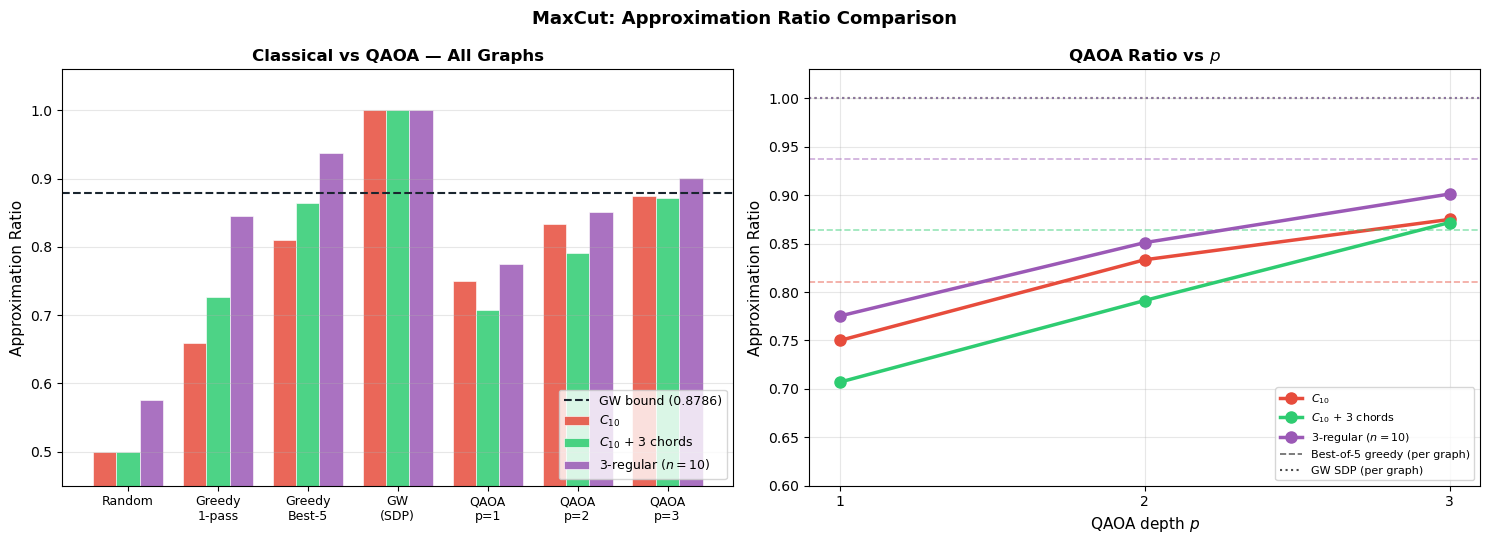

In [7]:
# ── Bar chart ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

x       = np.arange(len(COLS))
width   = 0.26
gcolors = ['#E74C3C', '#2ECC71', '#9B59B6']
names   = list(results.keys())

ax = axes[0]
for i, (name, r) in enumerate(results.items()):
    vals = [r[c] for c in COLS]
    ax.bar(x + (i-1)*width, vals, width, label=name,
           color=gcolors[i], alpha=0.85, edgecolor='white', linewidth=0.5)

ax.axhline(0.8786, color='#1A252F', ls='--', lw=1.5, label='GW bound (0.8786)')
ax.set_xticks(x)
ax.set_xticklabels(['Random', 'Greedy\n1-pass', 'Greedy\nBest-5', 'GW\n(SDP)',
                    'QAOA\np=1', 'QAOA\np=2', 'QAOA\np=3'], fontsize=9)
ax.set_ylabel('Approximation Ratio', fontsize=11)
ax.set_title('Classical vs QAOA — All Graphs', fontsize=12, fontweight='bold')
ax.set_ylim(0.45, 1.06)
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='y', alpha=0.3)

# ── p-scaling line plot ───────────────────────────────────────────
ax2 = axes[1]
for (name, r), gc in zip(results.items(), gcolors):
    qaoa_ratios = [r[f'QAOA p={p}'] for p in [1,2,3]]
    ax2.plot([1,2,3], qaoa_ratios, 'o-', color=gc, lw=2.5, ms=8, label=name)
    ax2.axhline(r['Best-5'], color=gc, ls='--', lw=1.2, alpha=0.5)
    ax2.axhline(r['GW'],     color=gc, ls=':',  lw=1.5, alpha=0.7)

ax2.plot([], [], 'k--', lw=1.2, alpha=0.6, label='Best-of-5 greedy (per graph)')
ax2.plot([], [], 'k:',  lw=1.5, alpha=0.7, label='GW SDP (per graph)')

ax2.set_xlabel('QAOA depth $p$', fontsize=11)
ax2.set_ylabel('Approximation Ratio', fontsize=11)
ax2.set_title('QAOA Ratio vs $p$', fontsize=12, fontweight='bold')
ax2.set_xticks([1,2,3]); ax2.set_ylim(0.6, 1.03)
ax2.legend(fontsize=8, loc='lower right')
ax2.grid(alpha=0.3)

plt.suptitle('MaxCut: Approximation Ratio Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('exp_results.png', dpi=130, bbox_inches='tight')
plt.show()

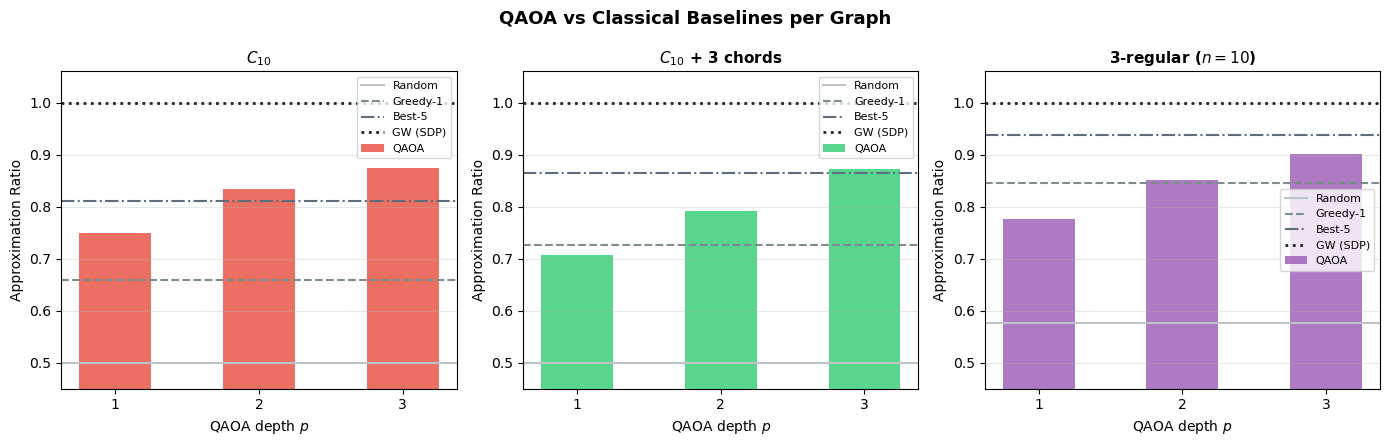

In [8]:
# ── p-dependence detail per graph ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, (name, r), gc in zip(axes, results.items(), gcolors):
    qaoa_ratios = [r[f'QAOA p={p}'] for p in [1,2,3]]
    ax.bar([1,2,3], qaoa_ratios, color=gc, alpha=0.8, width=0.5, label='QAOA')
    ax.axhline(r['Random'],   color='#BDC3C7', ls='-',  lw=1.5, label='Random')
    ax.axhline(r['Greedy-1'], color='#7F8C8D', ls='--', lw=1.5, label='Greedy-1')
    ax.axhline(r['Best-5'],   color='#5D6D7E', ls='-.',  lw=1.5, label='Best-5')
    ax.axhline(r['GW'],       color='#1A252F', ls=':',  lw=2,   label='GW (SDP)')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xticks([1,2,3]); ax.set_xlabel('QAOA depth $p$', fontsize=10)
    ax.set_ylabel('Approximation Ratio', fontsize=10)
    ax.set_ylim(0.45, 1.06)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('QAOA vs Classical Baselines per Graph', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('exp_per_graph.png', dpi=130, bbox_inches='tight')
plt.show()


### Discussion

**$C_{10}$ (cycle):**
QAOA achieves $0.750 \to 0.833 \to 0.875$ for $p=1,2,3$ — monotonically increasing,
consistent with the theoretical bound of $\geq 0.6924$ for $p=1$ on 2-regular graphs.
At $p=3$, QAOA surpasses Best-of-5 greedy.
GW finds OPT for this structured graph.

**$C_{10}$ + 3 chords:**
Adding long-range chords disrupts the local cycle structure.
Single-pass greedy drops to $0.726$ — it cannot resolve global connectivity
from purely local decisions.
QAOA $p=3$ achieves $0.872$, slightly above Best-of-5 greedy ($0.864$).
On this instance, QAOA $p=3$ outperforms best-of-5 greedy — consistent with QAOA's ability to capture longer-range correlations as $p$ increases, though this observation is limited to a single instance.

**3-regular ($n=10$):**
Best-of-5 greedy is strong ($0.937$) on this symmetric graph.
QAOA $p=3$ reaches $0.901$, approaching but not exceeding Best-of-5.
GW again finds OPT.

**On quantum advantage:**
QAOA's total cost is $O(T \cdot S \cdot p|E|)$, larger than a single greedy run.
The correct argument is about cost-quality scaling:
greedy's quality saturates as restarts $k$ grow (diminishing returns),
while QAOA's quality increases monotonically in $p$ at linear cost.
Whether QAOA at polynomial depth can match or exceed GW remains an open question. These small-instance experiments ($n=10$) are illustrative; they do not establish a scaling claim.


---
## References

- Farhi, Goldstone, Gutmann. "A quantum approximate optimization algorithm." arXiv:1411.4028 (2014).
- Goemans, Williamson. "Improved approximation algorithms for maximum cut." *JACM* 42, 1115–1145 (1995).
- Bravyi et al. "Obstacles to variational quantum optimization from symmetry protection." *PRL* 125, 260505 (2020).
